# DistilBERT
 DistilBERT is a compressed version of BERT designed to keep most of its language understanding, while being lighter and faster. The model is trained on huge amounts of text data using the knowledge distillation (a student model learns to mimic a teacher model) method to allow it to retain most of BERT's knowledge while being more efficient. DistilBERT uses BERT's architecture to create contextual embeddings - each token is represented based on the surrounding words, so the meaning of the word can change based on the context. The model outputs a vector, which captures the word meaning and the textual context.

## Load train/val/test sets
In this step, I will load the files from the split_data folder to ensure that every model is trained, tuned and evaluated on exactly the same input texts and labels. To load the data, I will use the "load_split_data" function from the `helper.py` file:

In [2]:
from utilities import helper

X_train, X_val, X_test, y_train, y_val, y_test = helper.load_split_data(show = True)
labels = list(y_train.columns)

X_train: (12122,)
X_val: (3742,)
X_test: (3742,)
y_train: (12122, 5)
y_val: (3742, 5)
y_test: (3742, 5)


## Remove non-label samples
In this step, I will filter out the non-label samples from all splits. These messages do not provide any learning signal to the models and can bias the results, because they dominate the dataset. By keeping only samples with at least one positive target, the model can focus on better distinguishing the 5 target variables:

In [3]:
import pandas as pd

def drop_no_label(X, y, labels):
    mask_keep = (y[labels].sum(axis=1) > 0)
    return X.loc[mask_keep].reset_index(drop=True), y.loc[mask_keep].reset_index(drop=True)

X_train, y_train = drop_no_label(X_train, y_train, labels)
X_val,   y_val   = drop_no_label(X_val,   y_val,   labels)
X_test,  y_test  = drop_no_label(X_test,  y_test,  labels)

## Build hugging face dataframe per split
In this step, I will build a Hugging face dataset object for each train, test and validation split. Hugging face datasets are efficient formats from the dataset library that stores the features and targets together and simplify the workflow of Transformers allowing the implementation of a *Trainer*. Additionally, I apply the text normalization used for the baseline models:

In [3]:
import numpy as np
from datasets import Dataset
import pandas as pd
from utilities.text_normalization import preprocess_text

def make_hf_split(X, y, label_cols):
           df = pd.concat([pd.Series(X, name="message").reset_index(drop=True),y.reset_index(drop=True)],axis=1)
           df["message"] = df["message"].apply(lambda t: preprocess_text(t, lemmatize=False))
           df[label_cols] = df[label_cols].astype(np.float32)
           labels_arr = df[label_cols].to_numpy(dtype=np.float32)
           labels_list = [row.tolist() for row in labels_arr]
           df = df.drop(columns=label_cols)
           df["labels"] = labels_list
           return Dataset.from_pandas(df, preserve_index=False)

train_ds = make_hf_split(X_train, y_train, labels)
val_ds   = make_hf_split(X_val, y_val, labels)
test_ds  = make_hf_split(X_test, y_test, labels)
train_ds

Dataset({
    features: ['message', 'labels'],
    num_rows: 12122
})

## Tokenize text
In this step, I load the DistilBERT's tokenizer, using the model's checkpoint from the Hugging Face Model Hub. Then, I create a simple function that creates input ids and attention masks for each message in the dataset. This is a crucial step because the input ids are the numerical token ids which the model can understand, while the attention mask helps the model distinguish which tokens are real and which are paddings. Paddings are included because messages usually have different lengths. The model is trained into batches, which require consistent length. Therefore, shorter messages are padded to match the set maximum length of 128 tokens:

In [5]:
from transformers import AutoTokenizer

distil_checkpoint = "distilbert/distilbert-base-uncased"
distil_tokenizer = AutoTokenizer.from_pretrained(distil_checkpoint)
def tok(batch):
    return distil_tokenizer(batch["message"], truncation=True, max_length=128)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)
test_ds  = test_ds.map(tok, batched=True)
train_ds

Map:   0%|          | 0/6061 [00:00<?, ? examples/s]

Map:   0%|          | 0/1299 [00:00<?, ? examples/s]

Map:   0%|          | 0/1299 [00:00<?, ? examples/s]

Dataset({
    features: ['message', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 6061
})

## Set dataset format for PyTorch
In this step, I keep only the columns required for training and convert them to PyTorch tensors - a multi-dimensional array of numbers used as standard input format for deep learning models:

In [6]:
cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)
train_ds

Dataset({
    features: ['message', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 6061
})

## Load model
In this step, I load the model using the "AutoModelForSequenceClassification" which is used to load pre-trained transformers model and add a classification layer. Then, I set the number of labels to the number of target variables and specify the task as a multi-label classification problem. This way the model is configured to produce independent predictions for each label. The warning below is expected as the original model was not specifically trained for my 5 target variables, so the classification head weights are randomly initialized and will be learned during training:

In [7]:
from transformers import AutoModelForSequenceClassification

distilbert = AutoModelForSequenceClassification.from_pretrained(
    distil_checkpoint,
    num_labels=len(labels),
    problem_type="multi_label_classification",
)
print(distilbert.config.num_labels)
print(distilbert.config.problem_type)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


5
multi_label_classification


## Fine-tune model
In this step, I fine-tune the pre-trained model for my multi-label classification task. First, I create a "sigmoid" and "compute_metrics" functions. I use the "sigmoid" one to convert each logit into a probability, which I later compare in the second function to a set threshold of a 0.5 to convert probabilities into binary predictions. Then, I use the *Training Arguments* to set rules of how the model should be trained - learning rate sets how big each weight update is, while epochs show the number of full passes through the dataset. Lastly, I use *Trainer* to execute the fine-tuning process. I add a callback for early stopping - when the validation loss does not improve after 2 epochs, the training stops. This is done to save time and prevent overfitting. By default, the *Trainer* automatically creates AdamW optimizer to update the model's weights during training.

In [8]:
import numpy as np
import torch
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import f1_score, hamming_loss, jaccard_score
from transformers import EarlyStoppingCallback, Trainer

data_collator = DataCollatorWithPadding(distil_tokenizer)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    y_pred = (probs >= 0.5).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

args = TrainingArguments(
    output_dir="distilbert_crisis",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available()
)

distil_trainer = Trainer(
    model=distilbert,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
distil_trainer.train()

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming,Jaccard Micro
1,0.325900,0.289125,0.801072,0.770039,0.102848,0.668157
2,0.250500,0.278022,0.807219,0.773561,0.103618,0.676753
3,0.211400,0.279475,0.809008,0.783850,0.103156,0.679272
4,0.173900,0.292499,0.810887,0.786674,0.103772,0.681925


TrainOutput(global_step=1516, training_loss=0.26764407400090967, metrics={'train_runtime': 88.7417, 'train_samples_per_second': 546.395, 'train_steps_per_second': 34.167, 'total_flos': 493926462850020.0, 'train_loss': 0.26764407400090967, 'epoch': 4.0})

## Evaluate with tuned per-label thresholds
In this step, I use the function "tune_per_label_thresholds" to tune a threshold for each label and select the one that produces the highest f1 score for that label. This allows harder labels to use more appropriate cutoffs, different from the ones used for more common labels. Then, the evaluation function, similar to the previous one, computes the overall metrics on the validation test using the selected thresholds to give a more realistic evaluation.

In [9]:
def tune_per_label_thresholds(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    L = y_true.shape[1]
    best_t = np.full(L, 0.5, dtype=float)
    best_f = np.zeros(L, dtype=float)

    for j in range(L):
        yj_true = y_true[:, j]
        if yj_true.sum() == 0:
            continue

        f1s = []
        for t in grid:
            yj_pred = (y_prob[:, j] >= t).astype(int)
            f1s.append(f1_score(yj_true, yj_pred, zero_division=0))

        k = int(np.argmax(f1s))
        best_t[j] = float(grid[k])
        best_f[j] = float(f1s[k])

    return best_t, best_f

def eval_with_thresholds(logits, y_true, thresholds):
    probs = sigmoid(logits)
    y_pred = (probs >= thresholds).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

val_pred = distil_trainer.predict(val_ds)
val_logits = val_pred.predictions
val_true   = val_pred.label_ids
val_probs = sigmoid(val_logits)

distil_best_t, distil_best_f = tune_per_label_thresholds(val_true, val_probs)

print("Per-label tuned thresholds (VAL):")
for name, t, f in zip(labels, distil_best_t, distil_best_f):
    print(f"{name:25s}  best_t={t:.2f}  val_f1={f:.3f}")

print("\nVAL overall metrics using tuned thresholds:")
print(eval_with_thresholds(val_logits, val_true, distil_best_t))

Per-label tuned thresholds (VAL):
need_basic_supplies        best_t=0.50  val_f1=0.938
need_medical_help          best_t=0.45  val_f1=0.774
need_safety_rescue         best_t=0.20  val_f1=0.697
need_shelter               best_t=0.60  val_f1=0.825
people_status              best_t=0.25  val_f1=0.731

VAL overall metrics using tuned thresholds:
{'micro_f1': 0.8136696501220505, 'macro_f1': 0.7928760784846436, 'hamming': 0.10577367205542725, 'jaccard_micro': 0.6858710562414266}


## Evaluation
Finally, to get a clear idea of the model's performance, I evaluate the DistilBERT on the test set using the tuned per-label thresholds. I use the same metrics, used for the evaluation of the baseline models - Micro and Macro F1, Hamming loss and Jaccard score. I save the results for later comparison and print a classification report to gain a better idea of which are the most challenging labels for the model:

In [10]:
test_pred = distil_trainer.predict(test_ds)
test_logits = test_pred.predictions
test_true   = test_pred.label_ids
test_probs  = 1 / (1 + np.exp(-test_logits))
test_pred_bin = (test_probs >= distil_best_t).astype(int)

test_metrics = eval_with_thresholds(test_logits, test_true, distil_best_t)
row = {"model": "DistilBERT",**test_metrics}
results_df = pd.DataFrame([row])
results_df.to_csv("../data/results/distilbert_results_new.csv", index=False)
results_df

,model,micro_f1,macro_f1,hamming,jaccard_micro
0,DistilBERT,0.802621,0.783104,0.115935,0.670315


In [11]:
from sklearn.metrics import classification_report

print(classification_report(test_true, test_pred_bin, target_names=labels, zero_division=0))

                     precision    recall  f1-score   support

need_basic_supplies       0.91      0.91      0.91       576
  need_medical_help       0.79      0.76      0.77       433
 need_safety_rescue       0.68      0.75      0.72       269
       need_shelter       0.90      0.75      0.82       355
      people_status       0.69      0.70      0.69       295

          micro avg       0.81      0.79      0.80      1928
          macro avg       0.79      0.78      0.78      1928
       weighted avg       0.82      0.79      0.80      1928
        samples avg       0.85      0.85      0.82      1928



DistilBERT shows strong overall performance on the test set, outperforming all TF-IDF baseline models. The classification report confirms the good generalization of the model, while *need_safety_rescue* adn *people_status* remainn the main challenge of this dataset due to divers pharsing.

## Save final model
 In this step, I save the final model weights and configuration, so the best model can be later reloaded. Additionally, I store the tokenizer and the tuned thresholds to ensure consistency during inference:

In [12]:
import numpy as np

save_dir = "../DistilBERT/distilbert_crisis_final_new"
distil_trainer.save_model(save_dir)
distil_tokenizer.save_pretrained(save_dir)
np.save(f"{save_dir}/best_thresholds.npy", distil_best_t)

## Inference

In [40]:
import numpy as np
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from utilities.text_normalization import preprocess_text

labels = ["need_basic_supplies","need_medical_help","need_safety_rescue","need_shelter","people_status"]
df_inf = pd.read_csv("../data/final/disaster_inference.csv")
idxs = [59, 45]

tokenizer = AutoTokenizer.from_pretrained(save_dir)
model = AutoModelForSequenceClassification.from_pretrained(save_dir)
best_t = np.load(f"{save_dir}/best_thresholds.npy")
model.to("cuda").eval()
texts = df_inf["message"].tolist()
y_true = df_inf[labels].values

sel = [preprocess_text(texts[i]) for i in idxs]
enc = tokenizer(sel, padding=True, truncation=True, max_length=128, return_tensors="pt").to("cuda")
with torch.no_grad():
    logits = model(**enc).logits
    probs_t = torch.sigmoid(logits)
probs = probs_t.cpu().numpy()
pred = (probs >= best_t.reshape(1, -1)).astype(int)

for k, i in enumerate(idxs):
    print("\nMESSAGE:", texts[i][:350].replace("\n"," "))
    print("True labels          :", [labels[j] for j in np.where(y_true[i] == 1)[0]])
    print("DistilBERT predicted :", [labels[j] for j in np.where(pred[k] == 1)[0]])



MESSAGE: I am asking for some help in Leogan Route Lamitye, Jakmel, Zone Makasin, 15th Section. We have note received any aid at all. I am asking for you to pass on this message. 
True labels          : []
DistilBERT predicted : []

MESSAGE: Help us here in Delmas 57 we need water and food and tents, please 
True labels          : ['need_basic_supplies', 'need_shelter']
DistilBERT predicted : ['need_basic_supplies', 'need_shelter']


# RoBERTa
RoBERTa (Robustly Optimized BERT Approach) is an improved variant of BERT that focuses on stronger pretraining. It is trained on significantly larger amounts of data and uses an optimized training strategy that includes dynamic masking and the removal of next sentence prediction. These changes allow RoBERTa to learn richer and more robust contextual representations. Like DistilBERT, RoBERTa produces contextual embeddings, where each token’s representation depends on its surrounding words.
I will reuse the same approach explained above for fine-tuning DistilBERT to implement this model.
## Tokenize text

In [45]:
from transformers import AutoTokenizer

roberta_checkpoint = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_checkpoint)
def tok(batch):
    return roberta_tokenizer(batch["message"], truncation=True, max_length=128)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)
test_ds  = test_ds.map(tok, batched=True)
train_ds

Map:   0%|          | 0/12122 [00:00<?, ? examples/s]

Map:   0%|          | 0/3742 [00:00<?, ? examples/s]

Map:   0%|          | 0/3742 [00:00<?, ? examples/s]

Dataset({
    features: ['message', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 12122
})

## Set dataset format for PyTorch

In [46]:
cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)
train_ds

Dataset({
    features: ['message', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 12122
})

## Load model

In [47]:
from transformers import AutoModelForSequenceClassification

roberta = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint,
    num_labels=len(labels),
    problem_type="multi_label_classification",
)
print(roberta.config.num_labels)
print(roberta.config.problem_type)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


5
multi_label_classification


## Fine-tune model

In [48]:
import numpy as np
import torch
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import f1_score, hamming_loss, jaccard_score
from transformers import EarlyStoppingCallback, Trainer

data_collator = DataCollatorWithPadding(roberta_tokenizer)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    y_pred = (probs >= 0.5).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

args = TrainingArguments(
    output_dir="roberta_crisis",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    weight_decay=0.02,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available()
)

roberta_trainer = Trainer(
    model=roberta,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming,Jaccard Micro
1,0.235300,0.191466,0.663090,0.638877,0.067130,0.495987
2,0.218200,0.187973,0.673690,0.643534,0.066221,0.507943
3,0.181200,0.194482,0.677711,0.654293,0.068626,0.512528
4,0.189400,0.202443,0.676537,0.654729,0.068894,0.511187


TrainOutput(global_step=3032, training_loss=0.21541924401134804, metrics={'train_runtime': 321.0194, 'train_samples_per_second': 302.088, 'train_steps_per_second': 18.89, 'total_flos': 1811771916302952.0, 'train_loss': 0.21541924401134804, 'epoch': 4.0})

## Evaluate with tuned per-label thresholds

In [49]:
def tune_per_label_thresholds(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    L = y_true.shape[1]
    best_t = np.full(L, 0.5, dtype=float)
    best_f = np.zeros(L, dtype=float)

    for j in range(L):
        yj_true = y_true[:, j]
        if yj_true.sum() == 0:
            continue

        f1s = []
        for t in grid:
            yj_pred = (y_prob[:, j] >= t).astype(int)
            f1s.append(f1_score(yj_true, yj_pred, zero_division=0))

        k = int(np.argmax(f1s))
        best_t[j] = float(grid[k])
        best_f[j] = float(f1s[k])

    return best_t, best_f

def eval_with_thresholds(logits, y_true, thresholds):
    probs = sigmoid(logits)
    y_pred = (probs >= thresholds).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

val_pred = roberta_trainer.predict(val_ds)
val_logits = val_pred.predictions
val_true   = val_pred.label_ids
val_probs = sigmoid(val_logits)

roberta_best_t, roberta_best_f = tune_per_label_thresholds(val_true, val_probs)

print("Per-label tuned thresholds (VAL):")
for name, t, f in zip(labels, roberta_best_t, roberta_best_f):
    print(f"{name:25s}  best_t={t:.2f}  val_f1={f:.3f}")

print("\nVAL overall metrics using tuned thresholds:")
print(eval_with_thresholds(val_logits, val_true, roberta_best_t))

Per-label tuned thresholds (VAL):
need_basic_supplies        best_t=0.75  val_f1=0.796
need_medical_help          best_t=0.45  val_f1=0.620
need_safety_rescue         best_t=0.45  val_f1=0.510
need_shelter               best_t=0.55  val_f1=0.727
people_status              best_t=0.35  val_f1=0.640

VAL overall metrics using tuned thresholds:
{'micro_f1': 0.6835781041388518, 'macro_f1': 0.6587496433130651, 'hamming': 0.06333511491181186, 'jaccard_micro': 0.5192697768762677}


## Evaluation

In [51]:
test_pred = roberta_trainer.predict(test_ds)
test_logits = test_pred.predictions
test_true   = test_pred.label_ids
test_probs  = 1 / (1 + np.exp(-test_logits))
test_pred_bin = (test_probs >= roberta_best_t).astype(int)

test_metrics = eval_with_thresholds(test_logits, test_true, roberta_best_t)
row = {"model": "RoBERTa",**test_metrics}
results_df = pd.DataFrame([row])
results_df.to_csv("../data/results/roberta_results.csv", index=False)
results_df

,model,micro_f1,macro_f1,hamming,jaccard_micro
0,RoBERTa,0.656432,0.629015,0.069375,0.488574


In [52]:
from sklearn.metrics import classification_report

print(classification_report(test_true, test_pred_bin, target_names=labels, zero_division=0))

                     precision    recall  f1-score   support

need_basic_supplies       0.76      0.79      0.77       576
  need_medical_help       0.61      0.56      0.58       433
 need_safety_rescue       0.57      0.46      0.51       269
       need_shelter       0.68      0.76      0.72       355
      people_status       0.62      0.52      0.56       295

          micro avg       0.67      0.64      0.66      1928
          macro avg       0.65      0.62      0.63      1928
       weighted avg       0.66      0.64      0.65      1928
        samples avg       0.26      0.24      0.24      1928



RoBERTa achieved micro f1 of  0.656, macro F1 of 0.629, hamming loss of 0.069 and Jaccard score of 0.489. Overall, this indicates moderate multi-label performance - the model identifies the most common need categories reasonably well, but performance remains uneven across labels. The poor lexical signal remians challenging for this transofmer.

# DeBERTa
DeBERTa (Decoding-enhanced BERT with Disentangled Attention) is a transformer-based language model that extends the BERT architecture by improving how attention is computed. Unlike the previous 2 models, DeBERTa disentangles the representations of content and position in the attention mechanism, allowing the model to better capture both word meaning and word order. In addition, DeBERTa uses an enhanced decoding scheme that improves the way contextual information is integrated during training. I will reuse the same fine-tuning and evaluation pipeline as for the other transformer models to ensure a fair comparison.
## Tokenize text

In [55]:
from transformers import AutoTokenizer

deb_checkpoint = "microsoft/deberta-v3-base"
deb_tokenizer = AutoTokenizer.from_pretrained(deb_checkpoint)
def tok(batch):
    return deb_tokenizer(batch["message"], truncation=True, max_length=128)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)
test_ds  = test_ds.map(tok, batched=True)
train_ds

C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/12122 [00:00<?, ? examples/s]

Map:   0%|          | 0/3742 [00:00<?, ? examples/s]

Map:   0%|          | 0/3742 [00:00<?, ? examples/s]

Dataset({
    features: ['message', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 12122
})

## Set dataset format for PyTorch

In [56]:
cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)
train_ds

Dataset({
    features: ['message', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 12122
})

## Load model

In [57]:
from transformers import AutoModelForSequenceClassification

deberta = AutoModelForSequenceClassification.from_pretrained(
    deb_checkpoint,
    num_labels=len(labels),
    problem_type="multi_label_classification",
)
print(deberta.config.num_labels)
print(deberta.config.problem_type)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


5
multi_label_classification


## Fine-tune model

In [58]:
import numpy as np
import torch
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import f1_score, hamming_loss, jaccard_score
from transformers import EarlyStoppingCallback, Trainer

data_collator = DataCollatorWithPadding(deb_tokenizer)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    y_pred = (probs >= 0.5).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

args = TrainingArguments(
    output_dir="deberta_crisis",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    warmup_ratio=0.1,
    weight_decay=0.02,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available()
)

deb_trainer = Trainer(
    model=deberta,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
deb_trainer.train()

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming,Jaccard Micro
1,0.267700,0.227449,0.620102,0.589748,0.083431,0.449383
2,0.219500,0.201921,0.651175,0.617486,0.073811,0.482772
3,0.175600,0.195846,0.676388,0.648351,0.067611,0.511017
4,0.146600,0.208389,0.683079,0.657264,0.065366,0.518693
5,0.153500,0.225019,0.673313,0.649556,0.068306,0.507514


TrainOutput(global_step=7580, training_loss=0.21255407827196146, metrics={'train_runtime': 1214.0159, 'train_samples_per_second': 79.88, 'train_steps_per_second': 9.99, 'total_flos': 1850044587323988.0, 'train_loss': 0.21255407827196146, 'epoch': 5.0})

## Evaluate with tuned per-label thresholds

In [59]:
def tune_per_label_thresholds(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    L = y_true.shape[1]
    best_t = np.full(L, 0.5, dtype=float)
    best_f = np.zeros(L, dtype=float)

    for j in range(L):
        yj_true = y_true[:, j]
        if yj_true.sum() == 0:
            continue

        f1s = []
        for t in grid:
            yj_pred = (y_prob[:, j] >= t).astype(int)
            f1s.append(f1_score(yj_true, yj_pred, zero_division=0))

        k = int(np.argmax(f1s))
        best_t[j] = float(grid[k])
        best_f[j] = float(f1s[k])

    return best_t, best_f

def eval_with_thresholds(logits, y_true, thresholds):
    probs = sigmoid(logits)
    y_pred = (probs >= thresholds).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

val_pred = deb_trainer.predict(val_ds)
val_logits = val_pred.predictions
val_true   = val_pred.label_ids
val_probs = sigmoid(val_logits)

deb_best_t, deb_best_f = tune_per_label_thresholds(val_true, val_probs)

print("Per-label tuned thresholds (VAL):")
for name, t, f in zip(labels, deb_best_t, deb_best_f):
    print(f"{name:25s}  best_t={t:.2f}  val_f1={f:.3f}")

print("\nVAL overall metrics using tuned thresholds:")
print(eval_with_thresholds(val_logits, val_true, deb_best_t))

Per-label tuned thresholds (VAL):
need_basic_supplies        best_t=0.80  val_f1=0.806
need_medical_help          best_t=0.55  val_f1=0.635
need_safety_rescue         best_t=0.35  val_f1=0.489
need_shelter               best_t=0.40  val_f1=0.742
people_status              best_t=0.65  val_f1=0.629

VAL overall metrics using tuned thresholds:
{'micro_f1': 0.6856840993132594, 'macro_f1': 0.6604398695825374, 'hamming': 0.06360235168359166, 'jaccard_micro': 0.5217041800643086}


## Evaluation

In [60]:
test_pred = deb_trainer.predict(test_ds)
test_logits = test_pred.predictions
test_true   = test_pred.label_ids
test_probs  = 1 / (1 + np.exp(-test_logits))
test_pred_bin = (test_probs >= deb_best_t).astype(int)

test_metrics = eval_with_thresholds(test_logits, test_true, deb_best_t)
row = {"model": "DeBERTa",**test_metrics}
results_df = pd.DataFrame([row])
results_df.to_csv("../data/results/deberta_results.csv", index=False)
results_df

,model,micro_f1,macro_f1,hamming,jaccard_micro
0,DeBERTa,0.669089,0.641292,0.068145,0.50273


In [61]:
from sklearn.metrics import classification_report

print(classification_report(test_true, test_pred_bin, target_names=labels, zero_division=0))

                     precision    recall  f1-score   support

need_basic_supplies       0.79      0.80      0.80       576
  need_medical_help       0.63      0.62      0.63       433
 need_safety_rescue       0.54      0.49      0.52       269
       need_shelter       0.67      0.75      0.71       355
      people_status       0.59      0.53      0.56       295

          micro avg       0.67      0.67      0.67      1928
          macro avg       0.64      0.64      0.64      1928
       weighted avg       0.67      0.67      0.67      1928
        samples avg       0.26      0.25      0.25      1928



Overall, Deberta scored slightly lower results than DistilBERT - micro f1 = 0.669, macro f1 = 0.641, hamming loss = 0.068 and jaccard score = 0.502. The similarity between these scores suggests that DeBERTa is learning essentially the same underlying dataset signal as the other transformer models, rather than uncovering substantially new predictive patterns. Additionally, similar to the previous 2 transformers the classification report indicates that the weak lexical signal captured by the chi-square diagram in the data provisioning notebook is challenging even for the transformer models.

# Comparison

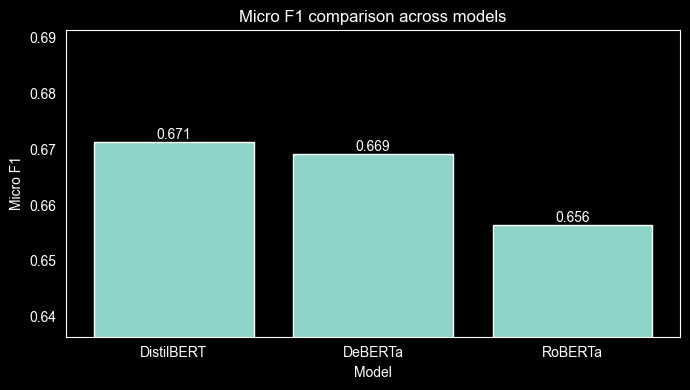

In [89]:
import matplotlib.pyplot as plt

distil_bert = pd.read_csv("../data/results/distilBert_results.csv")
rob = pd.read_csv("../data/results/roberta_results.csv")
deb = pd.read_csv("../data/results/deberta_results.csv")

df_micro = pd.DataFrame({
    "model": ["DistilBERT", "DeBERTa", "RoBERTa"],
    "micro_f1": [
        float(distil_bert["micro_f1"].iloc[0]),
        float(deb["micro_f1"].iloc[0]),
        float(rob["micro_f1"].iloc[0]),
    ]
}).sort_values("micro_f1", ascending=False)

ymin = max(0, df_micro["micro_f1"].min() - 0.02)
ymax = min(1, df_micro["micro_f1"].max() + 0.02)

plt.figure(figsize=(7,4))
ax = plt.gca()

bars = ax.bar(df_micro["model"], df_micro["micro_f1"])
ax.set_title("Micro F1 comparison across models")
ax.set_xlabel("Model")
ax.set_ylabel("Micro F1")
ax.set_ylim(ymin, ymax)

ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

The chart above shows the comparison of the 3 transformer models - DistilBERT achieves the highest performance, followed very closely by DeBERTa, while RoBERTa performs slightly worse. The small differences between the models indicate that they all managed to capture the same underlying signal in the data. Despite architectural and pretraining differences, none of the transformer models provides a substantial advantage over the others.

# QWEN 2.5
Qwen 2.5 is a decoder-based large language model developed to support a wide range of natural language tasks. Unlike encoder-only models such as BERT, Qwen 2.5 has a causal transformer architecture and is primarily pretrained for generative language modeling. The model is trained on large-scale multilingual text data and is designed to capture broad linguistic and semantic knowledge. To adapt Qwen 2.5 for the multi-label classification task, a classification head is attached to the model and LoRA adapters are used during fine-tuning.
## Tokenize text

In [4]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tok(batch):
    return tokenizer(batch["message"],truncation=True,padding="max_length",max_length=128)

train_ds = train_ds.map(tok, batched=True, remove_columns=["message"])
val_ds   = val_ds.map(tok, batched=True, remove_columns=["message"])
test_ds  = test_ds.map(tok, batched=True, remove_columns=["message"])

train_ds.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
val_ds.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
test_ds.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
train_ds

Map:   0%|          | 0/12122 [00:00<?, ? examples/s]

Map:   0%|          | 0/3742 [00:00<?, ? examples/s]

Map:   0%|          | 0/3742 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 12122
})

## Load model

In [6]:
import torch
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    problem_type="multi_label_classification",
    torch_dtype=torch.float16
)

model.config.pad_token_id = tokenizer.pad_token_id
print(model.config.num_labels)
print(model.config.problem_type)

Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-1.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


5
multi_label_classification


## Attach LoRA
In this step, I attach the LoRA(Low-Rank Adaptation) adapters to the model. LoRA is a
parameter-efficient fine-tuning method, which freezes the original weights and adds small trainable matrices
on top of selected layers. During training, only these extra parameters are updated, which makes fine-tuning
much lighter and reduces the risk of overfitting,
 - r - the rank of the matrices; controls the number of new parameters, while giving enough capacity to
learn
 - lora_alpha - scaling factors that controls how strong the LoRA update is applied
 - lora_dropout - drops some adapters during training to avoid overfitting
 - target_modules - the attention projections we adapt:
    -  q_proj (query)- a vector that represents what this token is looking for in the sentence
    - k_proj (key)- a vector that represents how relevant this token is to other tokens
    - v_proj (value)- the actual information that will be shared with other tokens
    - o_proj (output)- takes the mixed values from all tokens and turns them back into the next
hidden state

In [7]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    modules_to_save=["score"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 4,365,824 || all params: 1,548,087,808 || trainable%: 0.2820


## Fina-tune model

In [8]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding
from sklearn.metrics import f1_score, hamming_loss, jaccard_score
import numpy as np
from scipy.special import expit
import os
os.environ["ACCELERATE_MIXED_PRECISION"] = "no"

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    probs = expit(logits)
    y_pred = (probs >= 0.5).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

model.gradient_checkpointing_enable()
model.config.use_cache = False
data_collator = DataCollatorWithPadding(tokenizer)

args = TrainingArguments(
    output_dir="qwen25_1p5b_seqcls_lora",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    max_grad_norm=1.0,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=200,
    save_steps=200,
    save_total_limit=2,
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    gradient_checkpointing=False
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()
trainer.save_model("qwen25_1p5b_seqcls_qlora_final")

C:\Users\katit\AppData\Local\Temp\ipykernel_13120\3923996147.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming,Jaccard Micro
200,8.293900,0.776122,0.225140,0.212849,0.170337,0.126849
400,7.846800,0.732168,0.243815,0.228752,0.158471,0.138832
600,7.862200,0.707621,0.253895,0.244442,0.156120,0.145407
800,7.102800,0.691715,0.260411,0.253392,0.157563,0.149697
1000,7.131100,0.672478,0.268241,0.257491,0.149011,0.154895
1200,6.404800,0.662541,0.282460,0.267318,0.151523,0.164456
1400,6.612300,0.649229,0.293430,0.267607,0.145430,0.171942
1600,6.954900,0.651160,0.297163,0.279953,0.150935,0.174510
1800,5.650700,0.638625,0.291318,0.276201,0.144842,0.170493
2000,6.722700,0.636611,0.304425,0.281437,0.147034,0.179541


C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils\checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
C:\Users\katit\PycharmProjects\CHC\.venv\Lib\site-packages\torch\utils

## Evaluate with tuned per-label thresholds

In [10]:
import numpy as np
from sklearn.metrics import f1_score, hamming_loss, jaccard_score

def sigmoid(x):
    return  expit(x)

def tune_per_label_thresholds(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    L = y_true.shape[1]
    best_t = np.full(L, 0.5, dtype=float)
    best_f = np.zeros(L, dtype=float)

    for j in range(L):
        yj_true = y_true[:, j]
        if yj_true.sum() == 0:
            continue

        f1s = []
        for t in grid:
            yj_pred = (y_prob[:, j] >= t).astype(int)
            f1s.append(f1_score(yj_true, yj_pred, zero_division=0))

        k = int(np.argmax(f1s))
        best_t[j] = float(grid[k])
        best_f[j] = float(f1s[k])

    return best_t, best_f

def eval_with_thresholds(logits, y_true, thresholds):
    probs = sigmoid(logits)
    y_pred = (probs >= thresholds).astype(int)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_micro": jaccard_score(y_true, y_pred, average="micro", zero_division=0),
    }

val_pred  = trainer.predict(val_ds)
val_logits = val_pred.predictions
val_true   = val_pred.label_ids

val_true = np.asarray(val_true).astype(int)
val_probs = sigmoid(val_logits)
best_t, best_f = tune_per_label_thresholds(val_true, val_probs)

print("Per-label tuned thresholds (VAL):")
for name, t, f in zip(labels, best_t, best_f):
    print(f"{name:25s}  best_t={t:.2f}  val_f1={f:.3f}")

print("\nVAL overall metrics using tuned thresholds:")
print(eval_with_thresholds(val_logits, val_true, best_t))

Per-label tuned thresholds (VAL):
need_basic_supplies        best_t=0.60  val_f1=0.735
need_medical_help          best_t=0.40  val_f1=0.523
need_safety_rescue         best_t=0.05  val_f1=0.267
need_shelter               best_t=0.15  val_f1=0.657
people_status              best_t=0.10  val_f1=0.529

VAL overall metrics using tuned thresholds:
{'micro_f1': 0.5912162162162162, 'macro_f1': 0.5425063869650714, 'hamming': 0.07760555852485301, 'jaccard_micro': 0.4196642685851319}


## Evaluate

In [11]:
import numpy as np

test_pred   = trainer.predict(test_ds)
test_logits = test_pred.predictions
test_true   = np.asarray(test_pred.label_ids).astype(int)
test_probs = expit(test_logits)
test_pred_bin = (test_probs >= best_t).astype(int)

test_metrics = eval_with_thresholds(test_logits, test_true, best_t)

row = {"model": "QWEN", **test_metrics}
results_df = pd.DataFrame([row])
results_df.to_csv("../data/results/qwen_results.csv", index=False)
results_df

C:\Users\katit\AppData\Local\Temp\ipykernel_9984\1034027586.py:6: RuntimeWarning: overflow encountered in exp
  test_probs = 1 / (1 + np.exp(-test_logits))


,model,micro_f1,macro_f1,hamming,jaccard_micro
0,QWEN,0.582186,0.530069,0.079476,0.410622


In [12]:
from sklearn.metrics import classification_report

print(classification_report( test_true,test_pred_bin,target_names=labels,zero_division=0))

                     precision    recall  f1-score   support

need_basic_supplies       0.69      0.76      0.72       576
  need_medical_help       0.50      0.57      0.53       433
 need_safety_rescue       0.72      0.20      0.31       269
       need_shelter       0.74      0.56      0.64       355
      people_status       0.63      0.35      0.45       295

          micro avg       0.64      0.54      0.58      1928
          macro avg       0.66      0.49      0.53      1928
       weighted avg       0.65      0.54      0.56      1928
        samples avg       0.21      0.20      0.20      1928



The weaker performance of Qwen 2.5 compared to DistilBERT can be explained by the dataset imbalance, especially the limited number of positive examples for the harder labels and the overlap between categories. Qwen shows low recall for *need_safety_rescue* and *people_status*, which indicates the model struggles to lear  reliable decision boundaries for rare and ambiguous classes. In contrast, DistilBERT is an encoder model designed to fine-tune more reliably on smaller datasets, which can make it a stronger and more stable choice in this project. Overall, the results suggest that the main limitation in the current state of this project is the dataset signal rather than the model choice.

## Save model

In [15]:
from pathlib import Path
import json
import numpy as np

out_dir = Path("../LLM/qwen_seqcls")
out_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(out_dir))
tokenizer.save_pretrained(str(out_dir))

np.save(out_dir / "best_thresholds.npy", best_t)

with open(out_dir / "labels.json", "w", encoding="utf-8") as f:
    json.dump(labels, f, indent=2)